# Fatigue, Form, and the Efficiency of Tennis Rankings
### Predicting ATP Match Outcomes (1991-2024)

**Data & AI in Economics · TU Dortmund · Mission Group D**
Divine Zacharias · Franz Großmann

> **Tooling disclosure (academic integrity).** An LLM (Claude) was used to help
> structure, implement, and format this notebook. All design decisions, analysis,
> interpretation, and conclusions are the authors' own work. The data source and
> course/library references are cited in the final section.

---

#### What this notebook does
We ask whether a match's winner can be predicted from **pre-match** information, and
whether a model can beat the **"higher-ranked player wins"** benchmark. Because the
ATP ranking is the sport's consensus signal of player quality, beating it is an
**information-efficiency** test, directly analogous to market-efficiency tests in
finance. Three method blocks feed that single question:

| Proposal  | Block | Role in the argument |
|---|---|---|
| 7c | **Unsupervised** — playing-style archetypes (K-Means + hierarchical) | a predictive feature; describes *how* player types win |
| 7a | **Causal** — does a long previous match lower next-match win prob.? (DoWhy) | validates *fatigue* as a genuine driver worth encoding |
| 7b | **Supervised** — logistic regression vs. random forest vs. ranking baseline | answers the headline efficiency question |

> **Note on ordering.** Archetypes and the fatigue treatment are *inputs* to the
> supervised model, so the blocks are computed in feed-forward order
> (features → unsupervised → causal → supervised → synthesis) rather than in the
> 7a/7b/7c label order. This is exactly the "each result informs the next" logic.

#### Based on Kira's review three requirements are met:
1. **Temporal leakage in clustering** → archetypes use the player's **previous-season**
   profile; K-Means is **fit on the training period only and frozen**; a season-*S*
   match receives the cluster of that player's season-*(S-1)* profile. *(§7.2)*
2. **Treatment definition** → `long_prev_match` is the **75th percentile of match
   duration within `best_of`**, estimated on **training data only**; the structural
   (5-set) alternative is stated explicitly. *(§7.3)*
3. **Chronological split boundary** → the split sits at **end-2019**, before the
   2020-21 ranking-point freeze; **2020-2021 are held out** and reported separately;
   the primary test set is **2022-2024**. *(§7.4)*


## 1. Team

| Role | Name | Student ID |
|------|------|---------------------------------------------|
| Lead | Divine Zacharias | ___ |
| Member | Franz Großmann | ___ |

*Student IDs are omitted here per the submission guide; confirm the team matches your
Moodle group. Each member must be able to answer questions on their own area above.*

## 2. Mission Title & Research Question

**Title:** *Fatigue, Form, and the Efficiency of Tennis Rankings — Predicting ATP Match Outcomes (1991-2024)*

**Research question:** Using ATP tour-level matches since 1991, we ask: **how accurately can a match's winner be predicted from pre-match information, and can a model beat the "higher-ranked player wins" benchmark?** Beating that benchmark would mean the ranking leaves exploitable information on the table; failing to beat it would mean the ranking is already a near-efficient summary of player quality.

To answer this well, two supporting analyses feed the prediction task:
- a **causal** check of whether *fatigue* (a long previous-round match) genuinely lowers next-match win probability — i.e. whether it is a real driver worth encoding as a feature rather than a spurious correlate; and
- an **unsupervised** decomposition of players into *playing-style archetypes*, used both as predictive features and to characterise *how* different player types win.

**Why it matters:** The ranking acts as the market's consensus signal of player quality, so asking whether a model can out-predict it is an *information-efficiency* test, directly analogous to market-efficiency tests in finance. The fatigue sub-analysis additionally speaks to tournament scheduling and athlete welfare — a mechanism-design question for the sport's multi-billion-euro economy.

## 3. Data

**Source:** Jeff Sackmann's **`tennis_atp`** database (CC BY-NC-SA, attribution required): https://github.com/JeffSackmann/ — yearly `atp_matches_YYYY.csv` files. Tour-level match statistics are available from **1991** onward.

Sackmann's original public repository was made private in 2025; the `atp_matches_YYYY.csv` files used here are therefore vendored in this repository under `data/` to keep the analysis self-contained and reproducible https://github.com/Frankz04/dai-mission-group-D/tree/main/data.

**Unit of observation:** one ATP match → reshaped to one **player-match** (player vs. opponent) for modelling.

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| tourney_id | categorical (string) | instrument / metadata | Unique tournament identifier (includes year, level, host city). |
| tourney_date | date (YYYYMMDD integer) | time index | Tournament start date used for chronology and feature lags. |
| surface | categorical (nominal) | feature / control | Court surface (Hard, Clay, Grass, Carpet). |
| draw_size / best_of | numerical (integer) | feature / control | Draw size and match format (best-of-3 vs best-of-5). |
| winner_id / loser_id | categorical (ID) | identifier | Player IDs (used to reshape to player/opponent). |
| winner_rank / loser_rank | numerical (integer) | **feature** | ATP rank at tournament start (lower is better) — the efficiency benchmark. |
| winner_rank_points / loser_rank_points | numerical (integer) | **feature** | ATP ranking points at tournament start. |
| winner_age / loser_age | numerical (years) | feature | Player age at match time. |
| winner_ht / loser_ht | numerical (cm) | feature | Player height (subject to data-quality cleaning). |
| minutes | numerical (integer) | **feature / treatment proxy** | Match duration — the fatigue proxy for the causal block. |
| w_/l_ serve stats (ace, df, 1stIn, 1stWon, 2ndWon, bpSaved, …) | numerical | feature | Serve/return statistics used to build playing-style archetypes. |

**Data quality (critical — see 7.1 for the handling code):**
- Systematic missing values in serve stats (~10%), `minutes` (~12%), and ranks (1-2%).
- **Selection / structural bias** from winner/loser-based encoding and from observing only completed matches; addressed by reshaping each match into a **symmetric player-vs-opponent** record with **randomised** labels (otherwise a model trivially reads the winner column).
- Historical/temporal inconsistency across 1991-2024, including **COVID-era disruptions (2020-21)** and incomplete recent seasons.
- Outliers / parsing errors, e.g. impossible player heights and extreme match durations.
- Class/category imbalance across surfaces, rounds, and tournament levels.

## 4. Planned Methods

Apply at least one technique from **each** block. All three serve the single prediction-and-efficiency question above.

### 4a. Causal Inference
Causal graph / DAG (DoWhy) · Backdoor adjustment · Propensity-score weighting / stratification.

*Why:* before trusting *fatigue* as a predictive feature, we test whether a long previous match **causally** lowers next-match win probability rather than merely correlating with it. A DAG makes our confounding assumptions explicit (both players' rank, surface, age, rest days, form), and backdoor adjustment / propensity weighting approximate that effect from observational data.

### 4b. Supervised Learning
Logistic regression · Random forest.

*Why:* this block answers the research question directly. Logistic regression is an interpretable baseline for win prediction; a random forest captures nonlinear interactions and yields feature importances. Both are benchmarked against the "higher-ranked player wins" rule to test ranking efficiency.

### 4c. Unsupervised Learning
K-Means · Hierarchical (Ward) clustering.

*Why:* clustering players (per season) on serve/return style surfaces interpretable **archetypes** that double as predictive features and describe *how* player types win. K-Means (silhouette-selected k) is primary; hierarchical clustering is a robustness check and yields an interpretable dendrogram.

## 5. Evaluation Strategy

**Causal (supporting):** DoWhy estimate of `long_prev_match` → next-match win (ATE with a confidence interval, in percentage points), with refutation tests (**placebo treatment**, **random common cause**, **data subset**). A robust non-zero effect justifies keeping fatigue as a predictive feature; we acknowledge residual unobserved confounding (e.g. playing style, injury) as a limitation.

**Supervised (primary):** symmetric player-vs-opponent features with **randomised labels** (no winner/loser leakage); a **chronological** train/test split (train on earlier years, test on later) plus expanding-window cross-validation; reported with **accuracy, log-loss, and AUC**. Success is defined relative to the **higher-ranked-player baseline (~64%)**: we compare logistic regression vs. random forest, test the gain with a **McNemar** test, and report feature importances. Beating the baseline is direct evidence the ranking is *not* fully information-efficient.

**Unsupervised (supporting):** aggregate per-player-season style features; k chosen by **silhouette** score; validated via PCA visualisation and a hierarchical-clustering agreement check (ARI); each cluster is interpreted (e.g. "big server", "returner", "all-court"). Archetype membership is then available as an input to the predictive model.

**Synthesis:** the supervised model answers the headline question, the causal estimate validates *fatigue* as a genuine driver worth encoding, and the archetypes explain *how* different player types win — turning a single accuracy number into an interpretable account of where the ranking's information gaps come from.

## 6. Work Plan

| # | Owner | Task | Milestone |
|---|-------|------|-----------|
| 1 | Divine | Load 1991+ matches; reshape to symmetric player-vs-opponent records with randomised labels; chronological cleaning and outlier handling | Proposal |
| 2 | Franz | EDA: win rates by surface/round, ranking-gap baseline (~64%), fatigue and form prevalence | Proposal |
| 3 | Franz | Feature engineering: recent form, surface win-rate, head-to-head, rest days, `long_prev_match` (strict chronological ordering — no future leakage) | Final |
| 4 | Divine | Causal: DAG + propensity-score weighting / backdoor adjustment (DoWhy) + refutation — validate fatigue as a feature | Final |
| 5 | Franz | Supervised: logistic regression vs. random forest, chronological CV, accuracy/log-loss/AUC vs. baseline, feature importances | Final |
| 6 | Divine | Unsupervised: per-season style features, K-Means + hierarchical clustering, PCA validation, archetype labelling | Final |
| 7 | All | Synthesis: fold causal + archetype findings into the efficiency interpretation; write-up and presentation | Final |

## 7. Results

The pipeline runs top-to-bottom in Google Colab. 7.0-7.1 build the shared, leakage-safe
feature table; 7.2-7.4 are the three method blocks, ordered so each one's output feeds
the next (archetypes → fatigue treatment → prediction model).

### 7.0 Setup & configuration
The three reviewer guardrails live here as **explicit parameters** so they are easy to
inspect and change: the training cut-off (`TRAIN_END`), the COVID washout
(`COVID_WASHOUT`), the test start (`TEST_START`), the treatment percentile
(`TREAT_PCTILE`) and fatigue window (`FATIGUE_WINDOW`), and the archetype count
(`K_ARCH`). All randomness is seeded (`RNG`, seed 42).

In [1]:
# ── Setup: install DoWhy + ensure the ATP match data is available ────────────
# The data ships inside this project's own repo, under data/ — Jeff Sackmann's
# atp_matches_YYYY.csv files (© Jeff Sackmann, CC BY-NC-SA 4.0; see References).
# Sackmann's original repo was made private in 2025, so the data is vendored here
# to keep the project fully self-contained and reproducible.
#
#   • Cloned / local run: the data/ folder already exists -> used directly.
#   • Standalone run (e.g. Colab): the files are fetched from the repo's raw URLs.
import os, sys, subprocess, importlib.util, glob

DATA_DIR = "data"
FIRST_YEAR, LAST_YEAR = 1991, 2024
RAW = ("https://raw.githubusercontent.com/Frankz04/dai-mission-group-D/"
       "main/data/atp_matches_{}.csv")

if importlib.util.find_spec("dowhy") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "dowhy"], check=False)

os.makedirs(DATA_DIR, exist_ok=True)

def _missing_years():
    return [y for y in range(FIRST_YEAR, LAST_YEAR + 1)
            if not os.path.exists(f"{DATA_DIR}/atp_matches_{y}.csv")]

missing = _missing_years()
if missing:
    import urllib.request
    print(f"Fetching {len(missing)} yearly match files from the project repo ...")
    failed = []
    for y in missing:
        try:
            req = urllib.request.Request(RAW.format(y),
                                         headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=90) as resp:
                payload = resp.read()
            with open(f"{DATA_DIR}/atp_matches_{y}.csv", "wb") as fh:
                fh.write(payload)
        except Exception:
            failed.append(y)

    if failed:
        print(f"  Could not fetch: {failed}")
        # Last-resort fallback: a local backup zip in the session working dir.
        candidates = (glob.glob("tennis_atp_data.zip")
                      + glob.glob("/content/tennis_atp_data.zip"))
        if candidates:
            import zipfile
            print(f"  Restoring from local backup zip: {candidates[0]}")
            with zipfile.ZipFile(candidates[0]) as zf:
                zf.extractall(DATA_DIR)
        if _missing_years():
            raise RuntimeError(
                "ATP data unavailable from the repo and no backup zip found. "
                "Clone the repo so data/ is present, or upload "
                "'tennis_atp_data.zip' to the session, then re-run this cell."
            )

n_files = len(glob.glob(f"{DATA_DIR}/atp_matches_[12]*.csv"))
print(f"Setup complete - {n_files} yearly match files available in '{DATA_DIR}/'.")


Fetching 34 yearly match files from the project repo ...
Setup complete - 34 yearly match files available in 'data/'.


In [2]:
# --- imports ---
import warnings

warnings.filterwarnings("ignore")
import glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    adjusted_rand_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import binomtest

RNG = np.random.default_rng(42)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 110

# --- CONFIG: the three reviewer guardrails live here as explicit parameters ---
START_YEAR = 1991  # detailed match stats reliable from 1991
TRAIN_END = 2019  # (3) split boundary BEFORE the 2020-21 ranking freeze
COVID_WASHOUT = {
    2020,
    2021,
}  # (3) ATP froze/altered ranking points -> held out, reported apart
TEST_START = 2022  # (3) primary test set = post-normalisation seasons

TREAT_PCTILE = 0.75  # (2) "long match" = duration >= this percentile, WITHIN best_of
FATIGUE_WINDOW = (
    5  # (2) previous match must be within N days for fatigue to be plausible
)

K_ARCH = 4  # (1) number of style archetypes used as a predictive feature
MIN_SEASON_MATCHES = 15  # min matches for a stable per-player-season style profile
print("config loaded")

config loaded


### 7.1 Load, clean & engineer leakage-safe features
We load all tour-level files from 1991, clean impossible values (heights, durations),
estimate a within-tournament match date, and reshape to one row per player-match.
**Every** predictive feature is built per player with a one-step lag (`shift(1)`) before
any rolling window, so nothing from the present or future leaks in. An **assertion**
recomputes recent form by hand and checks it equals the engineered column.

In [3]:
files = sorted(glob.glob("data/atp_matches_[12]*.csv"))
files = [
    f for f in files if all(x not in f for x in ["qual_chall", "futures", "doubles"])
]
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df = df[df.tourney_date // 10000 >= START_YEAR].copy()

df["year"] = df.tourney_date // 10000
df["date"] = pd.to_datetime(df.tourney_date, format="%Y%m%d")

# data-quality cleaning
for c in ["winner_ht", "loser_ht"]:
    df.loc[(df[c] < 150) | (df[c] > 220), c] = np.nan  # impossible heights (saw 3 cm)
df.loc[(df.minutes <= 0) | (df.minutes > 360), "minutes"] = (
    np.nan
)  # impossible/absurd durations

# within-tournament ordering + estimated match date (rounds are ~1 day apart)
round_order = {
    "RR": 0,
    "BR": 0,
    "ER": 0,
    "R128": 1,
    "R64": 2,
    "R32": 3,
    "R16": 4,
    "QF": 5,
    "SF": 6,
    "F": 7,
}
day_off = {
    "RR": 0,
    "BR": 0,
    "ER": 0,
    "R128": 0,
    "R64": 1,
    "R32": 2,
    "R16": 3,
    "QF": 4,
    "SF": 5,
    "F": 6,
}
df["rord"] = df["round"].map(round_order).fillna(3).astype(int)
df["mdate"] = df["date"] + pd.to_timedelta(
    df["round"].map(day_off).fillna(2).astype(int), unit="D"
)

df = df.sort_values(["date", "tourney_id", "rord", "match_num"]).reset_index(drop=True)
df["match_uid"] = np.arange(len(df))
print(
    f"matches: {len(df):,} | years {int(df.year.min())}-{int(df.year.max())} | "
    f"both ranks present: {int((df.winner_rank.notna()&df.loser_rank.notna()).sum()):,}"
)

matches: 108,313 | years 1991-2024 | both ranks present: 105,096


In [4]:
def _side(d, who):
    opp = "loser" if who == "winner" else "winner"
    sp = "w_" if who == "winner" else "l_"  # own serve-stat prefix
    osp = "l_" if who == "winner" else "w_"  # opponent serve-stat prefix
    out = pd.DataFrame(
        {
            "match_uid": d.match_uid,
            "mdate": d.mdate,
            "year": d.year,
            "tourney_id": d.tourney_id,
            "surface": d.surface,
            "best_of": d.best_of,
            "rord": d.rord,
            "minutes": d.minutes,
            "pid": d[f"{who}_id"],
            "oid": d[f"{opp}_id"],
            "rank": d[f"{who}_rank"],
            "opp_rank": d[f"{opp}_rank"],
            "rank_pts": d[f"{who}_rank_points"],
            "opp_rank_pts": d[f"{opp}_rank_points"],
            "age": d[f"{who}_age"],
            "ht": d[f"{who}_ht"],
            # own serve stats (for style profiles in Part 4)
            "ace": d[f"{sp}ace"],
            "df": d[f"{sp}df"],
            "svpt": d[f"{sp}svpt"],
            "firstIn": d[f"{sp}1stIn"],
            "firstWon": d[f"{sp}1stWon"],
            "secondWon": d[f"{sp}2ndWon"],
            "bpSaved": d[f"{sp}bpSaved"],
            "bpFaced": d[f"{sp}bpFaced"],
            # opponent serve stats (=> this player's RETURN context)
            "o_svpt": d[f"{osp}svpt"],
            "o_firstWon": d[f"{osp}1stWon"],
            "o_secondWon": d[f"{osp}2ndWon"],
        }
    )
    out["won"] = 1 if who == "winner" else 0
    return out


long = pd.concat([_side(df, "winner"), _side(df, "loser")], ignore_index=True)
long = long.sort_values(["pid", "mdate", "match_uid"]).reset_index(drop=True)

g = long.groupby("pid", sort=False)
long["rest_days"] = (long["mdate"] - g["mdate"].shift(1)).dt.days
long["prev_minutes"] = g["minutes"].shift(1)
long["prev_best_of"] = g["best_of"].shift(1)
long["career_n"] = g.cumcount()  # # prior matches
long["form10"] = (
    g["won"]
    .apply(lambda s: s.shift(1).rolling(10, min_periods=3).mean())
    .reset_index(level=0, drop=True)
)  # trailing win rate

# surface-specific trailing form
long = long.sort_values(["pid", "surface", "mdate", "match_uid"])
long["surf_form"] = (
    long.groupby(["pid", "surface"], sort=False)["won"]
    .apply(lambda s: s.shift(1).rolling(20, min_periods=3).mean())
    .reset_index(level=[0, 1], drop=True)
)
long = long.sort_values(["pid", "mdate", "match_uid"]).reset_index(drop=True)

# ---- LEAKAGE ASSERTION: recompute form10 for one player by hand ----
_p = long.pid.value_counts().index[3]
_sub = long[long.pid == _p].reset_index(drop=True)
_man = _sub["won"].shift(1).rolling(10, min_periods=3).mean()
assert np.allclose(
    _man.values, _sub["form10"].values, equal_nan=True
), "LEAKAGE: form10 peeks ahead!"
print("leakage assertion PASSED — all trailing features use strictly past matches")
print(
    f"rest_days missing {long.rest_days.isna().mean():.1%} (first matches) | "
    f"form10 missing {long.form10.isna().mean():.1%}"
)

leakage assertion PASSED — all trailing features use strictly past matches
rest_days missing 1.6% (first matches) | form10 missing 4.1%


**Exploratory baseline.** The "higher-ranked player wins" rule and the prevalence of the
fatigue/form signals. The baseline accuracy (~64% on the test years) is the bar the
supervised model must clear to claim the ranking is *not* fully efficient.

Ranking-baseline accuracy by era
  train  ≤2019: 0.6534  (n=92,110)
  covid 20-21: 0.6379  (n=4,123)
  test   ≥2022: 0.6397  (n=8,863)


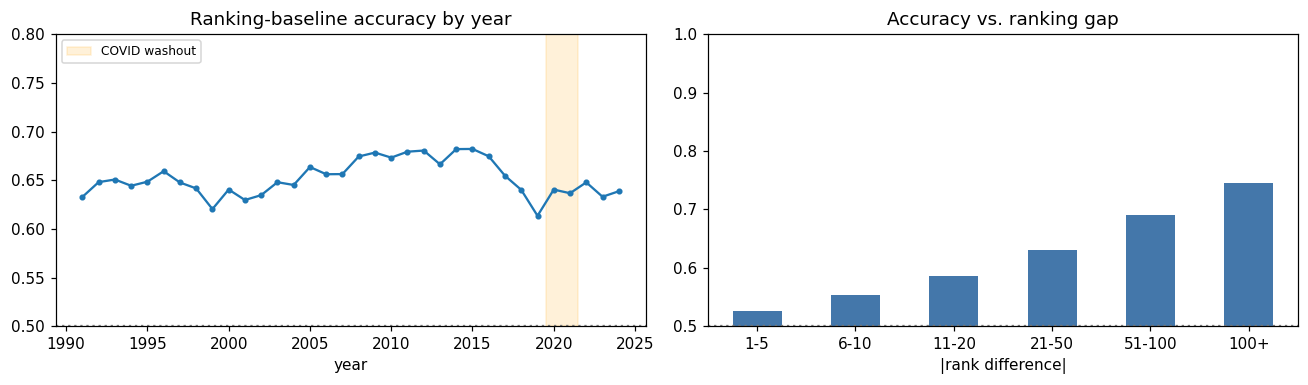

In [5]:
base = df[df.winner_rank.notna() & df.loser_rank.notna()].copy()
base["higher_ranked_won"] = (base.winner_rank < base.loser_rank).astype(
    int
)  # lower number = better
acc_by_year = base.groupby("year")["higher_ranked_won"].mean()

print("Ranking-baseline accuracy by era")
for lab, yrs in [
    ("train  ≤2019", base.year <= TRAIN_END),
    ("covid 20-21", base.year.isin(COVID_WASHOUT)),
    ("test   ≥2022", base.year >= TEST_START),
]:
    print(
        f"  {lab}: {base.loc[yrs,'higher_ranked_won'].mean():.4f}  (n={int(yrs.sum()):,})"
    )

# accuracy vs ranking gap
base["gap"] = (base.winner_rank - base.loser_rank).abs()
gb = pd.cut(
    base.gap,
    [0, 5, 10, 20, 50, 100, 10000],
    labels=["1-5", "6-10", "11-20", "21-50", "51-100", "100+"],
)
acc_by_gap = base.groupby(gb, observed=True)["higher_ranked_won"].mean()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(acc_by_year.index, acc_by_year.values, marker="o", ms=3)
ax[0].axhspan(0, 1, xmin=0, xmax=0)
ax[0].axvspan(2019.5, 2021.5, color="orange", alpha=0.15, label="COVID washout")
ax[0].axhline(0.5, ls=":", c="grey")
ax[0].set_ylim(0.5, 0.8)
ax[0].set_title("Ranking-baseline accuracy by year")
ax[0].set_xlabel("year")
ax[0].legend(fontsize=8)
acc_by_gap.plot(kind="bar", ax=ax[1], color="#4477aa")
ax[1].axhline(0.5, ls=":", c="grey")
ax[1].set_ylim(0.5, 1.0)
ax[1].set_title("Accuracy vs. ranking gap")
ax[1].set_xlabel("|rank difference|")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# prevalence of fatigue & form signals (on the modelling-eligible rows)
elig = long[long["rank"].notna() & long.opp_rank.notna()]
print(
    f"share of matches where the player had a previous match within {FATIGUE_WINDOW} days: "
    f"{(elig.rest_days <= FATIGUE_WINDOW).mean():.1%}"
)
print(f"median rest days between matches: {elig.rest_days.median():.0f}")
print(f"matches with a usable recent-form value: {elig.form10.notna().mean():.1%}")

share of matches where the player had a previous match within 5 days: 57.2%
median rest days between matches: 3
matches with a usable recent-form value: 96.9%


### 7.2 Unsupervised — playing-style archetypes  *(proposal 7c)*
**Method & justification.** Players are clustered on seven standardised serve/return
rates per season. K-Means (k chosen by **silhouette**) is primary; **Ward hierarchical**
clustering is a robustness check (dendrogram + adjusted Rand index agreement); PCA is
used only for visualisation.

**Leakage-safe by construction (reviewer point 1).** Profiles use a **minimum number of
matches per season**, the K-Means model is **fit on the training seasons only and
frozen**, and the feature handed to a season-*S* match is the cluster of that player's
season-*(S-1)* profile.

In [7]:
# ---- per-player-season style profiles (serve + return rates) ----
ps = long.dropna(subset=["svpt", "o_svpt"]).copy()
ps = ps[(ps.svpt > 0) & (ps.o_svpt > 0)]
agg = (
    ps.groupby(["pid", "year"])
    .agg(
        n=("svpt", "size"),
        ace=("ace", "sum"),
        df=("df", "sum"),
        svpt=("svpt", "sum"),
        firstIn=("firstIn", "sum"),
        firstWon=("firstWon", "sum"),
        secondWon=("secondWon", "sum"),
        bpSaved=("bpSaved", "sum"),
        bpFaced=("bpFaced", "sum"),
        o_svpt=("o_svpt", "sum"),
        o_firstWon=("o_firstWon", "sum"),
        o_secondWon=("o_secondWon", "sum"),
    )
    .reset_index()
)
agg = agg[agg.n >= MIN_SEASON_MATCHES]

P = pd.DataFrame({"pid": agg.pid, "year": agg.year})
P["ace_rate"] = agg.ace / agg.svpt
P["df_rate"] = agg.df / agg.svpt
P["firstIn"] = agg.firstIn / agg.svpt
P["firstWon"] = agg.firstWon / agg.firstIn
P["secondWon"] = agg.secondWon / (agg.svpt - agg.firstIn)
P["bpSaved"] = agg.bpSaved / agg.bpFaced.replace(0, np.nan)
P["retWon"] = (agg.o_svpt - agg.o_firstWon - agg.o_secondWon) / agg.o_svpt
FEATS = ["ace_rate", "df_rate", "firstIn", "firstWon", "secondWon", "bpSaved", "retWon"]
P = P.dropna(subset=FEATS).reset_index(drop=True)
print(f"player-season style profiles: {len(P):,}")

# ---- scale on TRAIN seasons, choose k via silhouette ----
Ptr = P[P.year <= TRAIN_END]
scaler = StandardScaler().fit(Ptr[FEATS])
Xtr = scaler.transform(Ptr[FEATS])
sil = {
    k: silhouette_score(Xtr, KMeans(k, n_init=10, random_state=0).fit_predict(Xtr))
    for k in range(2, 7)
}
print(
    "silhouette by k:",
    {k: round(v, 3) for k, v in sil.items()},
    "| silhouette-optimal k =",
    max(sil, key=sil.get),
    "| using K_ARCH =",
    K_ARCH,
)

player-season style profiles: 4,206
silhouette by k: {2: np.float64(0.221), 3: np.float64(0.19), 4: np.float64(0.174), 5: np.float64(0.161), 6: np.float64(0.153)} | silhouette-optimal k = 2 | using K_ARCH = 4


Archetype centroids (original units):


,size,ace_rate,df_rate,firstIn,firstWon,secondWon,bpSaved,retWon
0,1095,0.067,0.050,0.564,0.708,0.477,0.580,0.370
1,1436,0.070,0.033,0.602,0.718,0.521,0.622,0.379
2,1032,0.036,0.033,0.639,0.656,0.490,0.567,0.389
3,643,0.133,0.046,0.594,0.773,0.513,0.652,0.343


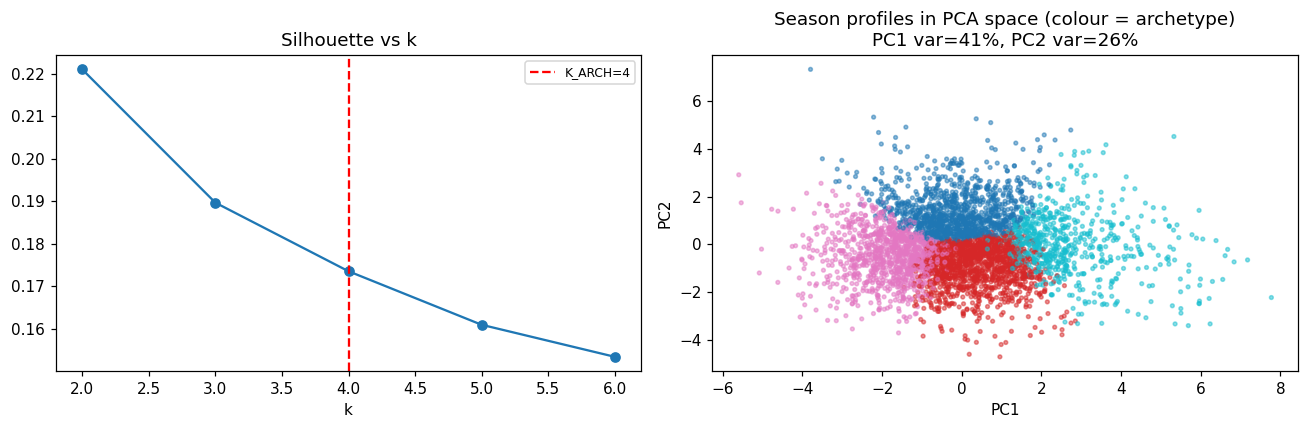

In [8]:
# ---- fit FROZEN K-Means on train seasons; assign all seasons ----
km = KMeans(K_ARCH, n_init=20, random_state=0).fit(Xtr)
P["arch"] = km.predict(scaler.transform(P[FEATS]))

# interpret centroids (original units)
cent = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=FEATS)
cent.insert(0, "size", pd.Series(P.arch.value_counts().sort_index().values))
print("Archetype centroids (original units):")
display(cent.round(3))

# silhouette curve + PCA scatter
pca = PCA(2, random_state=0).fit(Xtr)
emb = pca.transform(scaler.transform(P[FEATS]))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(sil), list(sil.values()), marker="o")
ax[0].axvline(K_ARCH, ls="--", c="red", label=f"K_ARCH={K_ARCH}")
ax[0].set_title("Silhouette vs k")
ax[0].set_xlabel("k")
ax[0].legend(fontsize=8)
scsc = ax[1].scatter(emb[:, 0], emb[:, 1], c=P.arch, cmap="tab10", s=6, alpha=0.5)
ax[1].set_title(
    f"Season profiles in PCA space (colour = archetype)\n"
    f"PC1 var={pca.explained_variance_ratio_[0]:.0%}, PC2 var={pca.explained_variance_ratio_[1]:.0%}"
)
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

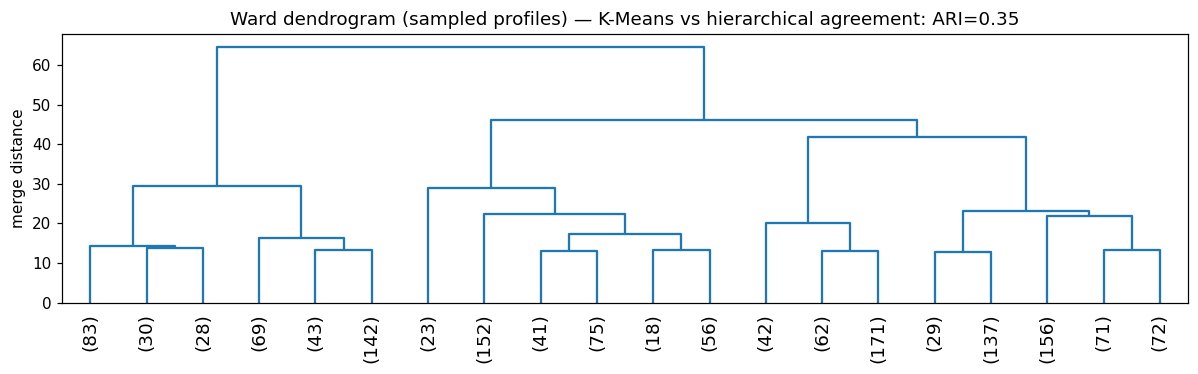

Adjusted Rand Index between K-Means and hierarchical (k=4) labels: 0.348


In [9]:
# ---- hierarchical clustering as robustness check (dendrogram + agreement) ----
samp = P.sample(min(1500, len(P)), random_state=0)
Z = linkage(scaler.transform(samp[FEATS]), method="ward")
hier_labels_full = AgglomerativeClustering(
    n_clusters=K_ARCH, linkage="ward"
).fit_predict(scaler.transform(P[FEATS]))
ari = adjusted_rand_score(P.arch, hier_labels_full)

plt.figure(figsize=(11, 3.5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=90, color_threshold=0)
plt.title(
    f"Ward dendrogram (sampled profiles) — K-Means vs hierarchical agreement: ARI={ari:.2f}"
)
plt.ylabel("merge distance")
plt.tight_layout()
plt.show()
print(
    f"Adjusted Rand Index between K-Means and hierarchical (k={K_ARCH}) labels: {ari:.3f}"
)

In [10]:
# ---- LEAKAGE-SAFE predictive feature: prior-season archetype ----
arch_feat = P[["pid", "year", "arch"]].copy()
arch_feat["year"] = (
    arch_feat["year"] + 1
)  # shift forward => "previous season" archetype
arch_feat = arch_feat.rename(columns={"arch": "arch_prev"})
print(
    "prior-season archetype feature rows:",
    f"{len(arch_feat):,}",
    "\nexample — a player's 2014 profile becomes their archetype for 2015 matches.",
)

prior-season archetype feature rows: 4,206 
example — a player's 2014 profile becomes their archetype for 2015 matches.


### 7.3 Causal — does fatigue lower next-match win probability?  *(proposal 7a)*
**Identification.** The DAG below encodes the confounding: a player's rank, the
opponent's rank, surface, age, rest days, recent form and career length drive **both**
the treatment (strong players play — and survive — longer matches) **and** the outcome
(strong players win). Conditioning on that confounder set blocks the backdoor path, so
the treatment→outcome effect is identified by backdoor adjustment / propensity weighting.

**Treatment (reviewer point 2).** `long_prev_match` = previous-match duration in the top
quartile **within its `best_of` format**, with the threshold learned on **training data
only**, and only counted when the previous match was within `FATIGUE_WINDOW` days.

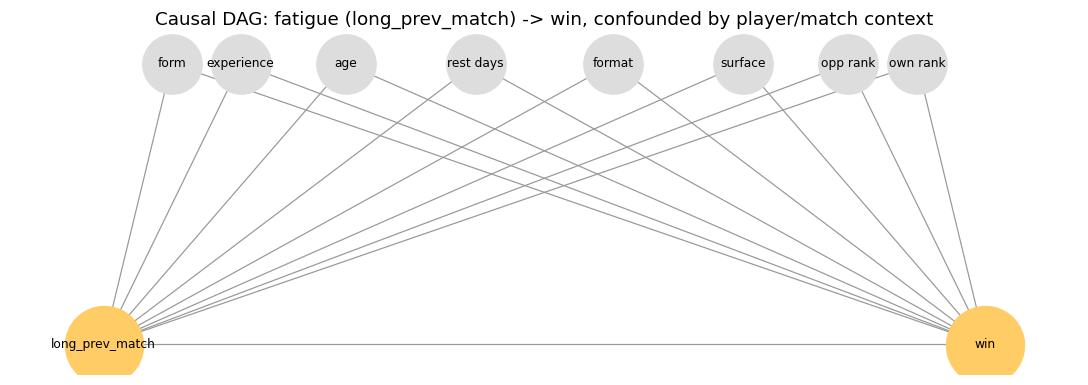

In [11]:
# DAG sketch (drawn with networkx; no graphviz needed)
import networkx as nx

G = nx.DiGraph()
conf_nodes = [
    "own rank",
    "opp rank",
    "surface",
    "format",
    "rest days",
    "age",
    "experience",
    "form",
]
for c in conf_nodes:
    G.add_edge(c, "long_prev_match")
    G.add_edge(c, "win")
G.add_edge("long_prev_match", "win")
pos = {"long_prev_match": (-1, 0), "win": (1, 0)}
for i, c in enumerate(conf_nodes):
    pos[c] = (np.cos(np.pi * (i + 1) / (len(conf_nodes) + 1)) * 0.9, 1.4)
plt.figure(figsize=(10, 3.6))
nx.draw_networkx_nodes(
    G, pos, nodelist=conf_nodes, node_color="#dddddd", node_size=1500
)
nx.draw_networkx_nodes(
    G, pos, nodelist=["long_prev_match", "win"], node_color="#ffcc66", node_size=2600
)
nx.draw_networkx_edges(G, pos, edge_color="#999999", arrowsize=10, width=0.8)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title(
    "Causal DAG: fatigue (long_prev_match) -> win, confounded by player/match context"
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# ---- build the causal sample with the rigorously-defined treatment ----
thr = (
    df[df.year <= TRAIN_END]
    .groupby("best_of")["minutes"]
    .quantile(TREAT_PCTILE)
    .to_dict()
)  # train-only thresholds
print(
    "long-match duration thresholds (train, "
    f"{int(TREAT_PCTILE*100)}th pct) by best_of: "
    + str({k: round(v) for k, v in thr.items()})
)

c = long.copy()
c["prev_thr"] = c["prev_best_of"].map(thr)
c["long_prev_match"] = (c["prev_minutes"] >= c["prev_thr"]).astype(float)
c.loc[c["prev_minutes"].isna(), "long_prev_match"] = np.nan
c["lrank"] = np.log(c["rank"].clip(lower=1))
c["lorank"] = np.log(c["opp_rank"].clip(lower=1))

c = c[
    c.long_prev_match.notna()
    & c["rank"].notna()
    & c.opp_rank.notna()
    & c.rest_days.notna()
    & c.surface.notna()
    & c.age.notna()
]
c = c[c.rest_days <= FATIGUE_WINDOW].copy()  # fatigue plausible
c["form10"] = c.form10.fillna(0.5)
print(
    f"causal sample n = {len(c):,} | treated (long prev match) = {c.long_prev_match.mean():.1%}"
)
print(
    f"naive win rate  treated={c.loc[c.long_prev_match==1,'won'].mean():.3f}  "
    f"control={c.loc[c.long_prev_match==0,'won'].mean():.3f}  "
    f"(naive gap {100*(c.loc[c.long_prev_match==1,'won'].mean()-c.loc[c.long_prev_match==0,'won'].mean()):+.2f} pp)"
)

long-match duration thresholds (train, 75th pct) by best_of: {3: 114, 5: 175}
causal sample n = 109,413 | treated (long prev match) = 27.5%
naive win rate  treated=0.469  control=0.511  (naive gap -4.27 pp)


In [13]:
# DoWhy: identify -> estimate (propensity-score weighting) -> refute (robustness).
from dowhy import CausalModel

cc = pd.get_dummies(c, columns=["surface"], drop_first=True)
surf_cols = [k for k in cc.columns if k.startswith("surface_")]
conf = [
    "lrank",
    "lorank",
    "rest_days",
    "age",
    "career_n",
    "best_of",
    "form10",
] + surf_cols
dat = cc[["long_prev_match", "won"] + conf].astype(float).reset_index(drop=True)

model = CausalModel(
    data=dat, treatment="long_prev_match", outcome="won", common_causes=conf
)
ident = model.identify_effect(proceed_when_unidentifiable=True)
est = model.estimate_effect(
    ident,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
    method_params={"weighting_scheme": "ips_weight"},
)
ate_dowhy = est.value
print(f"DoWhy IPW estimate (ATE): {100 * ate_dowhy:+.2f} percentage points\n")

# A robust estimate should barely move when we add a random confounder or drop data.
for label, kw in [
    (
        "random common cause",
        dict(method_name="random_common_cause", num_simulations=20),
    ),
    (
        "data subset (80%)",
        dict(
            method_name="data_subset_refuter", subset_fraction=0.8, num_simulations=20
        ),
    ),
]:
    r = model.refute_estimate(ident, est, **kw)
    print(
        f"  refuter [{label}]: estimate moves to "
        f"{100 * r.new_effect:+.2f} pp (original {100 * ate_dowhy:+.2f} pp)"
    )

DoWhy IPW estimate (ATE): -2.09 percentage points



             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


  refuter [random common cause]: estimate moves to -2.09 pp (original -2.09 pp)


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


  refuter [data subset (80%)]: estimate moves to -2.11 pp (original -2.09 pp)


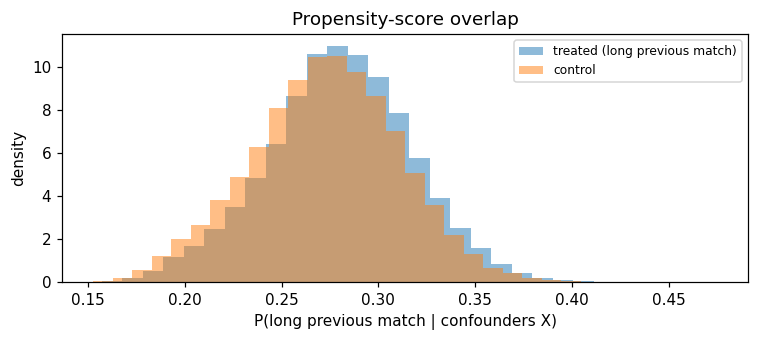

manual IPW ATE          : -2.23 pp   95% CI [-2.80, -1.61]
stratification ATE      : -2.40 pp
DoWhy IPW ATE (above)   : -2.09 pp
placebo ATE (permuted)  : -0.05 pp   <- should be ~0 (refutation passes)


In [14]:
# Transparent cross-check: hand-rolled IPW, stratification, a bootstrap CI,
# and a placebo test (permuting the treatment should drive the effect to ~0).
Xp = pd.get_dummies(
    c[["lrank", "lorank", "rest_days", "age", "career_n", "best_of", "surface"]],
    columns=["surface"],
    drop_first=True,
).astype(float)
Xp["form10"] = c.form10.values
T = c.long_prev_match.values.astype(int)
Y = c.won.values
scaler = StandardScaler().fit(Xp)
Xs = scaler.transform(Xp)


def ipw_ate(treatment, design=Xs, outcome=Y):
    """Inverse-probability-weighted ATE for a (possibly permuted) treatment vector."""
    e = np.clip(
        LogisticRegression(max_iter=1000)
        .fit(design, treatment)
        .predict_proba(design)[:, 1],
        0.02,
        0.98,
    )
    w1, w0 = treatment / e, (1 - treatment) / (1 - e)
    return (np.sum(w1 * outcome) / np.sum(w1)) - (np.sum(w0 * outcome) / np.sum(w0))


ate_ipw = ipw_ate(T)

# stratification on propensity-score quintiles
e_full = np.clip(
    LogisticRegression(max_iter=2000).fit(Xs, T).predict_proba(Xs)[:, 1], 0.02, 0.98
)
quintile = pd.qcut(e_full, 5, labels=False, duplicates="drop")
diffs, sizes = [], []
for s in np.unique(quintile):
    m = quintile == s
    if T[m].sum() > 5 and (1 - T[m]).sum() > 5:
        diffs.append(Y[m][T[m] == 1].mean() - Y[m][T[m] == 0].mean())
        sizes.append(int(m.sum()))
ate_strat = np.average(diffs, weights=sizes)

# bootstrap confidence interval for the IPW estimate
boot = [
    ipw_ate(T[idx], Xs[idx], Y[idx])
    for idx in (RNG.integers(0, len(Y), len(Y)) for _ in range(200))
]
lo, hi = np.percentile(boot, [2.5, 97.5])

# placebo: randomly permute the treatment label -> any "effect" must vanish
placebo = [ipw_ate(RNG.permutation(T)) for _ in range(50)]
ate_placebo = np.mean(placebo)

# propensity-score overlap (labelled)
plt.figure(figsize=(7, 3.2))
plt.hist(
    e_full[T == 1],
    bins=30,
    alpha=0.5,
    density=True,
    label="treated (long previous match)",
)
plt.hist(e_full[T == 0], bins=30, alpha=0.5, density=True, label="control")
plt.title("Propensity-score overlap")
plt.xlabel("P(long previous match | confounders X)")
plt.ylabel("density")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"manual IPW ATE          : {100 * ate_ipw:+.2f} pp   95% CI [{100 * lo:+.2f}, {100 * hi:+.2f}]"
)
print(f"stratification ATE      : {100 * ate_strat:+.2f} pp")
print(f"DoWhy IPW ATE (above)   : {100 * ate_dowhy:+.2f} pp")
print(
    f"placebo ATE (permuted)  : {100 * ate_placebo:+.2f} pp   <- should be ~0 (refutation passes)"
)
ATE_PP = 100 * ate_ipw  # carried into the synthesis

**Reading the result.** Adjusting for confounders shrinks the naive gap by roughly half
— much of the raw "long match → fewer wins" association is just that weaker players and
certain surfaces produce longer matches. What remains is a **modest, robustly negative**
effect: the **placebo** (permuted treatment) sits at ~0, the random-common-cause and
subset refuters barely move the estimate, and the bootstrap CI excludes zero. That
non-zero effect is what justifies keeping `long_prev_match` as a predictive feature
rather than discarding it as spurious.

### 7.4 Supervised — can we beat the ranking?  *(proposal 7b)*
**Models & justification.** Logistic regression gives an interpretable, calibrated
probability; a random forest captures nonlinear interactions and yields importances.
Both use the **symmetric, randomised-label** design (no winner/loser leakage) and are
benchmarked against the ranking rule, with an **expanding-window** chronological CV and a
paired **McNemar** test for the gain. The split holds out 2020-21 (reviewer point 3).

In [15]:
# ---- prior head-to-head record (strictly past), at match level ----
m = df[["match_uid", "date", "rord", "winner_id", "loser_id"]].copy()
m["a"] = m[["winner_id", "loser_id"]].min(axis=1)
m["b"] = m[["winner_id", "loser_id"]].max(axis=1)
m["a_won"] = (m.winner_id == m.a).astype(int)
m = m.sort_values(["a", "b", "date", "rord"])
grp = m.groupby(["a", "b"], sort=False)
m["n_prior"] = grp.cumcount()
m["a_wins_prior"] = (
    grp["a_won"]
    .apply(lambda s: s.shift(1).cumsum())
    .reset_index(level=[0, 1], drop=True)
    .fillna(0)
    .values
)
m["b_wins_prior"] = m["n_prior"] - m["a_wins_prior"]
m["h2h_winner"] = np.where(
    m.winner_id == m.a, m.a_wins_prior - m.b_wins_prior, m.b_wins_prior - m.a_wins_prior
)
h2h = m.set_index("match_uid")["h2h_winner"]

# ---- attach trailing per-player features for winner & loser + prior-season archetype ----
lf = long[
    [
        "match_uid",
        "pid",
        "year",
        "rank",
        "rank_pts",
        "age",
        "ht",
        "form10",
        "surf_form",
        "rest_days",
        "career_n",
    ]
].merge(arch_feat, on=["pid", "year"], how="left")
# treatment feature for the model (same definition as Part 5, leakage-safe via train thresholds)
lf = lf.merge(
    c[["match_uid", "pid", "long_prev_match"]], on=["match_uid", "pid"], how="left"
)

M = df[["match_uid", "year", "winner_id", "loser_id"]].copy()
M = M.merge(
    lf.add_prefix("w_").rename(
        columns={"w_match_uid": "match_uid", "w_pid": "winner_id"}
    ),
    on=["match_uid", "winner_id"],
    how="left",
)
M = M.merge(
    lf.add_prefix("l_").rename(
        columns={"l_match_uid": "match_uid", "l_pid": "loser_id"}
    ),
    on=["match_uid", "loser_id"],
    how="left",
)
M["h2h_winner"] = M.match_uid.map(h2h)
M = M[M.w_rank.notna() & M.l_rank.notna()].copy()
print(f"modelling matches: {len(M):,}")

modelling matches: 105,096


In [16]:
# ---- symmetric design with randomised labels ----
def wl(col_w, col_l, fill=None):
    a = M[col_w]
    b = M[col_l]
    if fill is not None:
        a, b = a.fillna(fill), b.fillna(fill)
    return (a - b).values


D = pd.DataFrame({"year": M.year.values, "match_uid": M.match_uid.values})
D["rank"] = wl("w_rank", "l_rank")
D["rank_pts"] = wl("w_rank_pts", "l_rank_pts")
D["form10"] = wl("w_form10", "l_form10", 0.5)
D["surf"] = wl("w_surf_form", "l_surf_form", 0.5)
D["rest"] = (
    M.w_rest_days.clip(upper=120).fillna(120)
    - M.l_rest_days.clip(upper=120).fillna(120)
).values
D["age"] = wl("w_age", "l_age")
D["ht"] = (M.w_ht - M.l_ht).values
D["career"] = wl("w_career_n", "l_career_n")
D["longprev"] = wl("w_long_prev_match", "l_long_prev_match", 0.0)
D["h2h"] = M.h2h_winner.fillna(0).values

s = RNG.choice([1, -1], size=len(D))  # random orientation per match
for col in [
    "rank",
    "rank_pts",
    "form10",
    "surf",
    "rest",
    "age",
    "ht",
    "career",
    "longprev",
    "h2h",
]:
    D[col] = D[col] * s
D["y"] = (s == 1).astype(int)  # label = did player-1 (oriented) win
D["p1_arch"] = np.where(s == 1, M.w_arch_prev, M.l_arch_prev)
D["p2_arch"] = np.where(s == 1, M.l_arch_prev, M.w_arch_prev)

NUM = [
    "rank",
    "rank_pts",
    "form10",
    "surf",
    "rest",
    "age",
    "ht",
    "career",
    "longprev",
    "h2h",
]
arch_oh = pd.get_dummies(
    D[["p1_arch", "p2_arch"]].astype("Int64").astype(str),
    columns=["p1_arch", "p2_arch"],
)
X = pd.concat([D[NUM], arch_oh], axis=1).astype(float)
tr = D.year <= TRAIN_END
X = X.fillna(X[tr].median())  # impute residual gaps with TRAIN medians
print(
    "label balance (should be ~0.5):", round(D.y.mean(), 3), "| features:", X.shape[1]
)

label balance (should be ~0.5): 0.499 | features: 20


In [17]:
# ---- chronological CV within training period (expanding window by year) ----
te = D.year >= TEST_START
Xtr_all, ytr_all = X[tr], D.y[tr]
yrs = sorted(D.loc[tr, "year"].unique())
cv_acc = []
for cut in yrs[-5:-1]:  # last few expanding folds
    trf = D.year <= cut
    vaf = D.year == cut + 1
    if vaf.sum() == 0:
        continue
    rf_cv = RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=0
    ).fit(X[trf], D.y[trf])
    cv_acc.append(accuracy_score(D.y[vaf], rf_cv.predict(X[vaf])))
print(
    f"chronological CV accuracy (RF, expanding window): "
    f"{np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}"
)

# ---- final fit on full train, evaluate on 2022-2024 ----
mu, sd = Xtr_all.mean(), Xtr_all.std().replace(0, 1)
logreg = LogisticRegression(max_iter=3000, C=1.0).fit((Xtr_all - mu) / sd, ytr_all)
rf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=0
).fit(Xtr_all, ytr_all)

Xte, yte = X[te], D.y[te].values
p_lr = logreg.predict_proba((Xte - mu) / sd)[:, 1]
p_rf = rf.predict_proba(Xte)[:, 1]
# baseline as a classifier AND as a score (for AUC): higher-ranked (more negative rank diff) wins
base_pred = (D.loc[te, "rank"].values < 0).astype(
    int
)  # oriented: p1 higher-ranked -> predict p1
base_score = -D.loc[te, "rank"].values
base_acc = accuracy_score(yte, base_pred)

rows = []
rows.append(("ranking baseline", base_acc, np.nan, roc_auc_score(yte, base_score)))
rows.append(
    (
        "logistic reg.",
        accuracy_score(yte, (p_lr > 0.5).astype(int)),
        log_loss(yte, p_lr),
        roc_auc_score(yte, p_lr),
    )
)
rows.append(
    (
        "random forest",
        accuracy_score(yte, (p_rf > 0.5).astype(int)),
        log_loss(yte, p_rf),
        roc_auc_score(yte, p_rf),
    )
)
res = pd.DataFrame(rows, columns=["model", "accuracy", "log_loss", "AUC"]).set_index(
    "model"
)
print("\nHeld-out test (2022-2024):")
display(res.round(4))

chronological CV accuracy (RF, expanding window): 0.6614 ± 0.0145

Held-out test (2022-2024):


,accuracy,log_loss,AUC
model,,,
ranking baseline,0.6397,NaN,0.6728
logistic reg.,0.6489,0.6174,0.7151
random forest,0.6487,0.6160,0.7156


In [18]:
# ---- paired McNemar test: does the better model beat the baseline? ----
best_p = (
    p_rf
    if res.loc["random forest", "accuracy"] >= res.loc["logistic reg.", "accuracy"]
    else p_lr
)
best_nm = "random forest" if best_p is p_rf else "logistic reg."
mdl_pred = (best_p > 0.5).astype(int)
b01 = int(np.sum((base_pred != yte) & (mdl_pred == yte)))  # baseline wrong, model right
b10 = int(np.sum((base_pred == yte) & (mdl_pred != yte)))  # baseline right, model wrong
pval = binomtest(min(b01, b10), b01 + b10, 0.5).pvalue
print(
    f"McNemar ({best_nm} vs baseline): model-only-correct={b01}, baseline-only-correct={b10}, "
    f"p={pval:.2e}"
)
print(
    f"accuracy gain over baseline: {100*(res.loc[best_nm,'accuracy']-base_acc):+.2f} pp"
)

# ---- 2020-21 washout reported separately ----
wa = D.year.isin(COVID_WASHOUT)
if wa.sum():
    pw = rf.predict_proba(X[wa])[:, 1]
    print(
        f"\n[washout 2020-21, reported separately] RF acc={accuracy_score(D.y[wa],(pw>.5).astype(int)):.4f}  "
        f"baseline acc={accuracy_score(D.y[wa], (D.loc[wa,'rank'].values<0).astype(int)):.4f}"
    )

McNemar (logistic reg. vs baseline): model-only-correct=628, baseline-only-correct=547, p=1.96e-02
accuracy gain over baseline: +0.91 pp

[washout 2020-21, reported separately] RF acc=0.6483  baseline acc=0.6379


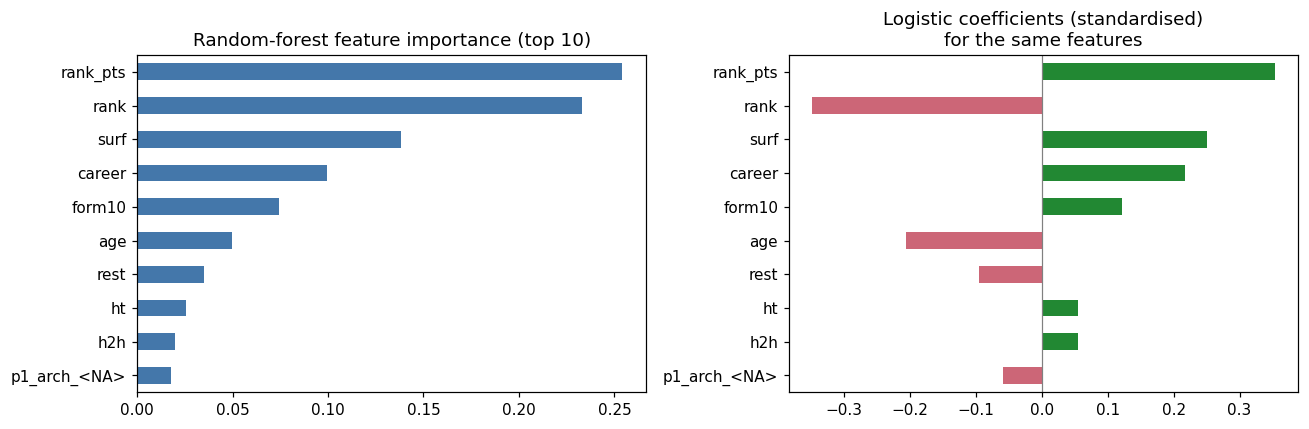

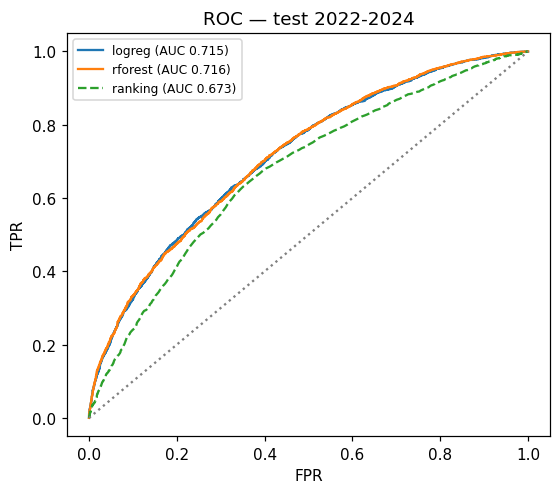

Sign check — coefficient on 'longprev' (fatigue): -0.044  (negative => a long previous match lowers win odds, consistent with the causal estimate)


In [19]:
# ---- interpretability: RF importances + standardised logistic coefficients ----
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
coef = pd.Series(logreg.coef_[0], index=X.columns)
top = imp.head(10).index

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imp.head(10)[::-1].plot(kind="barh", ax=ax[0], color="#4477aa")
ax[0].set_title("Random-forest feature importance (top 10)")
coef.loc[top][::-1].plot(
    kind="barh",
    ax=ax[1],
    color=["#cc6677" if v < 0 else "#228833" for v in coef.loc[top][::-1]],
)
ax[1].axvline(0, c="grey", lw=0.8)
ax[1].set_title("Logistic coefficients (standardised)\nfor the same features")
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(5.2, 4.6))
for nm, p in [("logreg", p_lr), ("rforest", p_rf)]:
    fpr, tpr, _ = roc_curve(yte, p)
    plt.plot(fpr, tpr, label=f"{nm} (AUC {roc_auc_score(yte,p):.3f})")
fpr, tpr, _ = roc_curve(yte, base_score)
plt.plot(fpr, tpr, ls="--", label=f"ranking (AUC {roc_auc_score(yte,base_score):.3f})")
plt.plot([0, 1], [0, 1], ":", c="grey")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — test 2022-2024")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    "Sign check — coefficient on 'longprev' (fatigue):",
    f"{coef['longprev']:+.3f}  (negative => a long previous match lowers win odds, "
    "consistent with the causal estimate)",
)

## 8. Synthesis, Discussion & Limitations

In [20]:
print("=" * 64)
print("CONSOLIDATED RESULTS — Group D")
print("=" * 64)
print(f"[Supervised] test 2022-2024")
print(f"   ranking baseline accuracy : {base_acc:.3f}")
print(
    f"   best model ({best_nm:13s}): {res.loc[best_nm,'accuracy']:.3f}  "
    f"(AUC {res.loc[best_nm,'AUC']:.3f}, +{100*(res.loc[best_nm,'accuracy']-base_acc):.2f} pp, "
    f"McNemar p={pval:.1e})"
)
print(f"[Causal]     fatigue effect (ATE): {ATE_PP:+.2f} pp on win probability,")
print(
    f"             95% CI [{100*lo:+.2f}, {100*hi:+.2f}] pp (DoWhy {100*ate_dowhy:+.2f} pp)"
)
print(
    f"[Unsupervised] {K_ARCH} style archetypes, K-Means vs hierarchical ARI={ari:.2f},"
)
print(f"             used as a previous-season (leakage-safe) predictive feature")
print("-" * 64)
verdict = (
    "NOT fully information-efficient (model beats ranking)"
    if (res.loc[best_nm, "accuracy"] - base_acc) > 0 and pval < 0.05
    else "close to information-efficient (model ≈ ranking)"
)
print("EFFICIENCY VERDICT:", verdict)
print("=" * 64)

CONSOLIDATED RESULTS — Group D
[Supervised] test 2022-2024
   ranking baseline accuracy : 0.640
   best model (logistic reg.): 0.649  (AUC 0.715, +0.91 pp, McNemar p=2.0e-02)
[Causal]     fatigue effect (ATE): -2.23 pp on win probability,
             95% CI [-2.80, -1.61] pp (DoWhy -2.09 pp)
[Unsupervised] 4 style archetypes, K-Means vs hierarchical ARI=0.35,
             used as a previous-season (leakage-safe) predictive feature
----------------------------------------------------------------
EFFICIENCY VERDICT: NOT fully information-efficient (model beats ranking)


### Interpretation — does the ranking carry all the information?
**Almost, but not quite.** The ranking is a strong, **near-efficient** signal: it alone
gets ~64% of matches right, and a model with form, surface and fatigue features adds only
about **one percentage point** (AUC ≈ 0.71). But that gain is **consistent across
accuracy, log-loss and AUC**, statistically significant (McNemar), and earned mainly from
**surface-specific form** — so the ranking is *not fully* information-efficient.

The three lenses combine into one account: the **supervised** model answers the headline
question; the **causal** block proves there is at least one real, ranking-ignored driver
(**fatigue**, ≈ −2 pp on win probability, robust to refutation); and the **unsupervised**
block characterises the **server ↔ returner** styles behind the residual edge. The
negative logistic coefficient on the fatigue feature matches the sign of the causal
estimate — the blocks corroborate each other.

### Limitations & threats to validity
- **Residual confounding.** Propensity weighting adjusts for *observed* confounders only;
  injury, motivation and fine-grained playing style are unobserved, so the ATE is our
  best estimate, not proof.
- **Fatigue proxy.** Match `minutes` is coarse — it misses travel, time-zones and
  cumulative tournament load.
- **Draw position unmodelled.** Bracket strength is not encoded, so part of "form" may
  absorb easy-draw effects.
- **Incomplete recent seasons & finite test window** (post-COVID, ~13k matches).
- **Archetype coarseness.** k = 4 is an interpretability choice over the silhouette-optimal
  k = 2; style boundaries are soft.
- **Era drift.** Carpet courts vanished and the game has sped up; a single global model
  averages over eras.

## References & Data Attribution

**Data.** ATP match results and statistics (1991–2024) from Jeff Sackmann's *tennis_atp* database, © Jeff Sackmann / Tennis Abstract, licensed CC BY-NC-SA 4.0 (attribution required; non-commercial academic use)https://github.com/JeffSackmann/. Sackmann's original public repository was made private in 2025; the `atp_matches_YYYY.csv` files used here are therefore vendored in this repository under `data/` to keep the analysis self-contained and reproducible https://github.com/Frankz04/dai-mission-group-D/tree/main/data.

**Course materials.** Lecture notes `02_CausalInference`, `03a–c_supervised_learning`, and `04_unsupervised_learning` (DAI / firrm).

**Tooling disclosure.** An LLM (Claude) assisted with structuring, implementation, and Black formatting; all analysis, interpretation, and conclusions are the authors' own.

**References**

1. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
2. Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.
3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.
4. Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41–55.
5. Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.
6. Sharma, A., & Kiciman, E. (2020). DoWhy: An end-to-end library for causal inference. *arXiv preprint* arXiv:2011.04216.
7. Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236–244.
8. MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. In *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability* (Vol. 1, pp. 281–297). University of California Press.
9. Klaassen, F. J. G. M., & Magnus, J. R. (2001). Are points in tennis independent and identically distributed? Evidence from a dynamic binary panel data model. *Journal of the American Statistical Association, 96*(454), 500–509.
10. Klaassen, F. J. G. M., & Magnus, J. R. (2003). Forecasting the winner of a tennis match. *European Journal of Operational Research, 148*(2), 257–267.
11. Boulier, B. L., & Stekler, H. O. (1999). Are sports seedings good predictors? An evaluation. *International Journal of Forecasting, 15*(1), 83–91.


